# Week 6: Land Price Variable

## Goals
- Read MLIT land price point data
- Merge prefectural files for the Tokyo metropolitan mainland study area
- Project to EPSG:6677
- Assign a land price proxy to municipal units

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_raw = project_root / "data_raw"

print(project_root)
print(data_raw)

e:\rsch\laborJapan
e:\rsch\laborJapan\data_raw


In [3]:
tokyo_path = data_raw / "tokyo_features_v1.geojson"
tokyo = gpd.read_file(tokyo_path)

print(tokyo.shape)
print(tokyo.crs)
tokyo.head()

(227, 13)
EPSG:6677


,N03_007,N03_001,N03_004,N03_005,total_pop,foreign_pop,foreign_ratio,dist_to_station_m,nearest_station_name,nearest_line_name,nearest_operator,log_dist_to_station_m,geometry
0,11101,埼玉県,さいたま市,西区,95251,1469,0.015422,1217.639796,指扇,川越線,東日本旅客鉄道,7.105491,"MULTIPOLYGON (((-25741.989 -7274.146, -25724.9..."
1,11102,埼玉県,さいたま市,北区,150366,2775,0.018455,376.317982,加茂宮,伊奈線,埼玉新都市交通,5.933088,"POLYGON ((-19464.582 -3877.533, -19423.753 -38..."
2,11103,埼玉県,さいたま市,大宮区,124703,3389,0.027177,18.735225,大宮,東北線,東日本旅客鉄道,2.982405,"POLYGON ((-17656.644 -8549.615, -17623.916 -85..."
3,11104,埼玉県,さいたま市,見沼区,165105,3594,0.021768,1005.052129,七里,野田線,東武鉄道,6.913789,"POLYGON ((-14986.573 -3932.152, -14966.946 -39..."
4,11105,埼玉県,さいたま市,中央区,103107,2061,0.019989,94.227971,与野本町,東北線,東日本旅客鉄道,4.556274,"POLYGON ((-19047.367 -10824.812, -19007.183 -1..."


In [5]:
land_dir = data_raw / "landPrice"

saitama_path = land_dir / "L01-24_11_GML" / "L01-24_11.geojson"
chiba_path = land_dir / "L01-24_12_GML" / "L01-24_12.geojson"
tokyo_path_lp = land_dir / "L01-24_13_GML" / "L01-24_13.geojson"
kanagawa_path = land_dir / "L01-24_14_GML" / "L01-24_14.geojson"

print("saitama exists:", saitama_path.exists())
print("chiba exists:", chiba_path.exists())
print("tokyo exists:", tokyo_path_lp.exists())
print("kanagawa exists:", kanagawa_path.exists())

saitama exists: True
chiba exists: True
tokyo exists: True
kanagawa exists: True


In [6]:
saitama_lp = gpd.read_file(saitama_path)
chiba_lp = gpd.read_file(chiba_path)
tokyo_lp = gpd.read_file(tokyo_path_lp)
kanagawa_lp = gpd.read_file(kanagawa_path)

print("saitama:", saitama_lp.shape)
print("chiba:", chiba_lp.shape)
print("tokyo:", tokyo_lp.shape)
print("kanagawa:", kanagawa_lp.shape)
print("CRS:", tokyo_lp.crs)

saitama: (1301, 145)
chiba: (1259, 145)
tokyo: (2602, 145)
kanagawa: (1787, 145)
CRS: EPSG:6668


In [8]:
print("saitama:", saitama_lp.crs)
print("chiba:", chiba_lp.crs)
print("tokyo:", tokyo_lp.crs)
print("kanagawa:", kanagawa_lp.crs)

saitama: EPSG:4326
chiba: EPSG:4326
tokyo: EPSG:6668
kanagawa: EPSG:6668


In [9]:
saitama_lp = saitama_lp.to_crs(epsg=6677)
chiba_lp = chiba_lp.to_crs(epsg=6677)
tokyo_lp = tokyo_lp.to_crs(epsg=6677)
kanagawa_lp = kanagawa_lp.to_crs(epsg=6677)

print("saitama:", saitama_lp.crs)
print("chiba:", chiba_lp.crs)
print("tokyo:", tokyo_lp.crs)
print("kanagawa:", kanagawa_lp.crs)

saitama: EPSG:6677
chiba: EPSG:6677
tokyo: EPSG:6677
kanagawa: EPSG:6677


In [10]:
landprice = pd.concat(
    [saitama_lp, chiba_lp, tokyo_lp, kanagawa_lp],
    ignore_index=True
)

landprice = gpd.GeoDataFrame(landprice, geometry="geometry", crs="EPSG:6677")

print(landprice.shape)
print(landprice.crs)

(6949, 145)
EPSG:6677


In [11]:
print(saitama_lp.columns.tolist())
print(chiba_lp.columns.tolist())
print(tokyo_lp.columns.tolist())
print(kanagawa_lp.columns.tolist())

['L01_001', 'L01_002', 'L01_003', 'L01_004', 'L01_005', 'L01_006', 'L01_007', 'L01_008', 'L01_009', 'L01_010', 'L01_011', 'L01_012', 'L01_013', 'L01_014', 'L01_015', 'L01_016', 'L01_017', 'L01_018', 'L01_019', 'L01_020', 'L01_021', 'L01_022', 'L01_023', 'L01_024', 'L01_025', 'L01_026', 'L01_027', 'L01_028', 'L01_029', 'L01_030', 'L01_031', 'L01_032', 'L01_033', 'L01_034', 'L01_035', 'L01_036', 'L01_037', 'L01_038', 'L01_039', 'L01_040', 'L01_041', 'L01_042', 'L01_043', 'L01_044', 'L01_045', 'L01_046', 'L01_047', 'L01_048', 'L01_049', 'L01_050', 'L01_051', 'L01_052', 'L01_053', 'L01_054', 'L01_055', 'L01_056', 'L01_057', 'L01_058', 'L01_059', 'L01_060', 'L01_061', 'L01_062', 'L01_063', 'L01_064', 'L01_065', 'L01_066', 'L01_067', 'L01_068', 'L01_069', 'L01_070', 'L01_071', 'L01_072', 'L01_073', 'L01_074', 'L01_075', 'L01_076', 'L01_077', 'L01_078', 'L01_079', 'L01_080', 'L01_081', 'L01_082', 'L01_083', 'L01_084', 'L01_085', 'L01_086', 'L01_087', 'L01_088', 'L01_089', 'L01_090', 'L01_091'

In [12]:
print(landprice.columns.tolist()[:25])

['L01_001', 'L01_002', 'L01_003', 'L01_004', 'L01_005', 'L01_006', 'L01_007', 'L01_008', 'L01_009', 'L01_010', 'L01_011', 'L01_012', 'L01_013', 'L01_014', 'L01_015', 'L01_016', 'L01_017', 'L01_018', 'L01_019', 'L01_020', 'L01_021', 'L01_022', 'L01_023', 'L01_024', 'L01_025']


In [13]:
landprice.head(3).T

,0,1,2
L01_001,11101,11101,11101
L01_002,000,000,000
L01_003,001,002,003
L01_004,11101,11101,11101
L01_005,000,000,000
...,...,...,...
L01_141,10000000000000,10000000000000,10000000000000
L01_142,10000000000000,10000000000000,10000000000000
L01_143,10000000000000,10000000000000,10000000000000
L01_144,10000000000000,10000000000000,10000000000000


In [14]:
sample_cols = landprice.columns.tolist()[:20]
landprice[sample_cols].head(3).T

,0,1,2
L01_001,11101,11101,11101
L01_002,000,000,000
L01_003,001,002,003
L01_004,11101,11101,11101
L01_005,000,000,000
L01_006,001,002,003
L01_007,2024,2024,2024
L01_008,103000,43300,140000
L01_009,2.0,0.0,2.9
L01_010,1,1,1


In [15]:
res_lp = landprice[landprice["L01_002"].astype(str) == "000"].copy()

print(res_lp.shape)
res_lp[["L01_001", "L01_002", "L01_007", "L01_008"]].head()

(5037, 145)


,L01_001,L01_002,L01_007,L01_008
0,11101,000,2024,103000
1,11101,000,2024,43300
2,11101,000,2024,140000
3,11101,000,2024,118000
4,11101,000,2024,122000


In [16]:
res_lp["L01_008"] = pd.to_numeric(res_lp["L01_008"], errors="coerce")
res_lp = res_lp[res_lp["L01_008"] > 0].copy()

print(res_lp["L01_008"].describe())
print("Missing price values:", res_lp["L01_008"].isna().sum())

count    5.037000e+03
mean     2.650487e+05
std      3.193609e+05
min      5.300000e+03
25%      9.950000e+04
50%      1.790000e+05
75%      3.180000e+05
max      5.350000e+06
Name: L01_008, dtype: float64
Missing price values: 0


In [17]:
tokyo_path = data_raw / "tokyo_features_v1.geojson"
tokyo = gpd.read_file(tokyo_path)
tokyo_proj = tokyo.to_crs(epsg=6677)

print(tokyo_proj.shape)
print(tokyo_proj.crs)

(227, 13)
EPSG:6677


In [18]:
joined_lp = gpd.sjoin(
    res_lp,
    tokyo_proj[["N03_007", "geometry"]],
    how="inner",
    predicate="within"
)

print(joined_lp.shape)
joined_lp.head()

(4984, 147)


,L01_001,L01_002,L01_003,L01_004,L01_005,L01_006,L01_007,L01_008,L01_009,L01_010,...,L01_138,L01_139,L01_140,L01_141,L01_142,L01_143,L01_144,geometry,index_right,N03_007
0,11101,000,001,11101,000,001,2024,103000,2.0,1,...,10000000100000,10000000000000,10000000000000,10000000000000,10000000000000,10000000000000,10000000000000,POINT (-21605.202 -10680.692),0,11101
1,11101,000,002,11101,000,002,2024,43300,0.0,1,...,10000000000000,10000000000000,10000000000000,10000000000000,10000000000000,10000000000000,10000000000000,POINT (-23227.362 -11201.904),0,11101
2,11101,000,003,11101,000,003,2024,140000,2.9,1,...,10000000000000,10000000000000,10000000000000,10000000000000,10000000000000,10000000000000,10000000000000,POINT (-24014.969 -8907.746),0,11101
3,11101,000,004,11101,000,004,2024,118000,2.6,1,...,10000000000000,10000000000000,10000000000000,10000000000000,10000000000000,10000000000000,10000000000000,POINT (-23974.472 -9687.046),0,11101
4,11101,000,005,11101,000,005,2024,122000,2.5,1,...,10000000100000,10000000000000,10000000000000,10000000000000,10000000000000,10000000000000,10000000000000,POINT (-23269.598 -10131.491),0,11101


In [19]:
district_price = (
    joined_lp.groupby("N03_007")["L01_008"]
    .median()
    .reset_index()
    .rename(columns={"L01_008": "median_land_price_jpy"})
)

print(district_price.shape)
district_price.head()

(218, 2)


,N03_007,median_land_price_jpy
0,11101,118000.0
1,11102,173000.0
2,11103,283000.0
3,11104,110000.0
4,11105,308500.0


In [20]:
tokyo_proj = tokyo_proj.merge(district_price, on="N03_007", how="left")

print(tokyo_proj[["N03_007", "foreign_ratio", "dist_to_station_m", "median_land_price_jpy"]].head())
print("Missing land price:", tokyo_proj["median_land_price_jpy"].isna().sum())

  N03_007  foreign_ratio  dist_to_station_m  median_land_price_jpy
0   11101       0.015422        1217.639796               118000.0
1   11102       0.018455         376.317982               173000.0
2   11103       0.027177          18.735225               283000.0
3   11104       0.021768        1005.052129               110000.0
4   11105       0.019989          94.227971               308500.0
Missing land price: 9


In [21]:
tokyo_proj[
    tokyo_proj["N03_004"].astype(str).str.contains("川口|江戸川", na=False) |
    tokyo_proj["N03_005"].astype(str).str.contains("川口|江戸川", na=False)
][[
    "N03_001", "N03_004", "N03_005", "N03_007",
    "foreign_ratio", "dist_to_station_m", "median_land_price_jpy"
]]

,N03_001,N03_004,N03_005,N03_007,foreign_ratio,dist_to_station_m,median_land_price_jpy
12,埼玉県,川口市,,11203,0.071131,300.302318,223000.0
138,東京都,江戸川区,,13123,0.062204,919.207429,398000.0


In [22]:
print("Missing land price:", tokyo_proj["median_land_price_jpy"].isna().sum())

Missing land price: 9


In [23]:
tokyo_proj[
    tokyo_proj["N03_004"].astype(str).str.contains("川口|江戸川", na=False) |
    tokyo_proj["N03_005"].astype(str).str.contains("川口|江戸川", na=False)
][[
    "N03_001", "N03_004", "N03_005",
    "foreign_ratio", "dist_to_station_m", "median_land_price_jpy"
]]

,N03_001,N03_004,N03_005,foreign_ratio,dist_to_station_m,median_land_price_jpy
12,埼玉県,川口市,,0.071131,300.302318,223000.0
138,東京都,江戸川区,,0.062204,919.207429,398000.0


In [24]:
tokyo_proj["median_land_price_jpy"] = pd.to_numeric(
    tokyo_proj["median_land_price_jpy"], errors="coerce"
)

tokyo_proj["median_land_price_jpy"].describe()

count    2.180000e+02
mean     2.172296e+05
std      3.270263e+05
min      1.130000e+04
25%      6.111250e+04
50%      1.320000e+05
75%      2.483750e+05
max      3.340000e+06
Name: median_land_price_jpy, dtype: float64

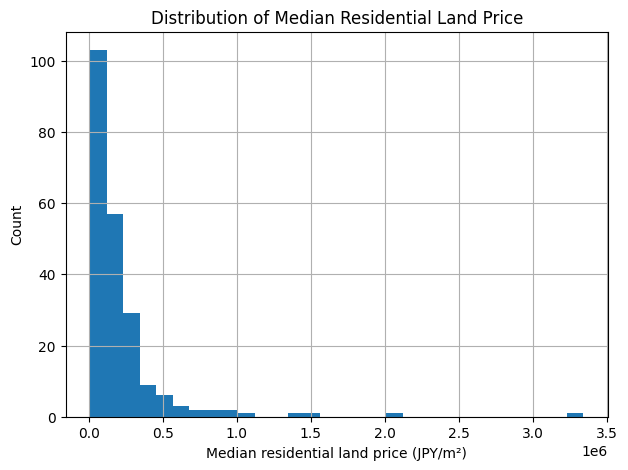

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))

tokyo_proj["median_land_price_jpy"].dropna().hist(bins=30, ax=ax)

ax.set_title("Distribution of Median Residential Land Price")
ax.set_xlabel("Median residential land price (JPY/m²)")
ax.set_ylabel("Count")

plt.show()

In [26]:
tokyo_proj["log_median_land_price_jpy"] = np.log1p(tokyo_proj["median_land_price_jpy"])

tokyo_proj[["median_land_price_jpy", "log_median_land_price_jpy"]].describe()

,median_land_price_jpy,log_median_land_price_jpy
count,2.180000e+02,218.000000
mean,2.172296e+05,11.749580
std,3.270263e+05,1.012919
min,1.130000e+04,9.332646
25%,6.111250e+04,11.020488
50%,1.320000e+05,11.790558
75%,2.483750e+05,12.422668
max,3.340000e+06,15.021482


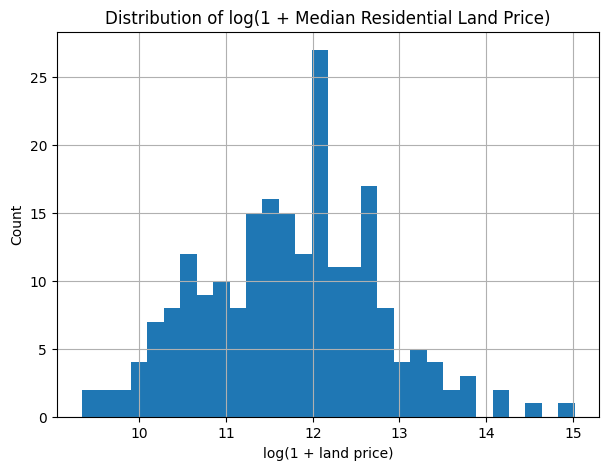

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))

tokyo_proj["log_median_land_price_jpy"].dropna().hist(bins=30, ax=ax)

ax.set_title("Distribution of log(1 + Median Residential Land Price)")
ax.set_xlabel("log(1 + land price)")
ax.set_ylabel("Count")

plt.show()

In [28]:
corr_df2 = tokyo_proj[
    ["foreign_ratio", "log_dist_to_station_m", "log_median_land_price_jpy"]
].corr()

corr_df2

,foreign_ratio,log_dist_to_station_m,log_median_land_price_jpy
foreign_ratio,1.000000,-0.333295,0.385542
log_dist_to_station_m,-0.333295,1.000000,-0.521899
log_median_land_price_jpy,0.385542,-0.521899,1.000000


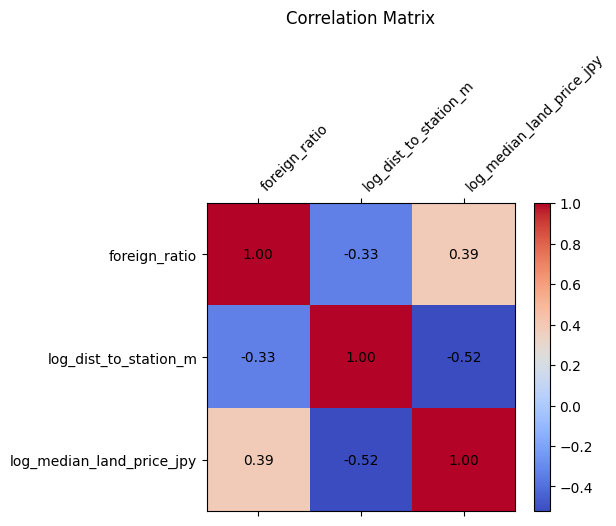

In [29]:
fig, ax = plt.subplots(figsize=(5, 4))

cax = ax.matshow(corr_df2, cmap="coolwarm")
fig.colorbar(cax)

ax.set_xticks(range(len(corr_df2.columns)))
ax.set_yticks(range(len(corr_df2.columns)))
ax.set_xticklabels(corr_df2.columns, rotation=45, ha="left")
ax.set_yticklabels(corr_df2.columns)

for i in range(len(corr_df2.index)):
    for j in range(len(corr_df2.columns)):
        ax.text(j, i, f"{corr_df2.iloc[i, j]:.2f}", va="center", ha="center")

ax.set_title("Correlation Matrix", pad=20)
plt.show()

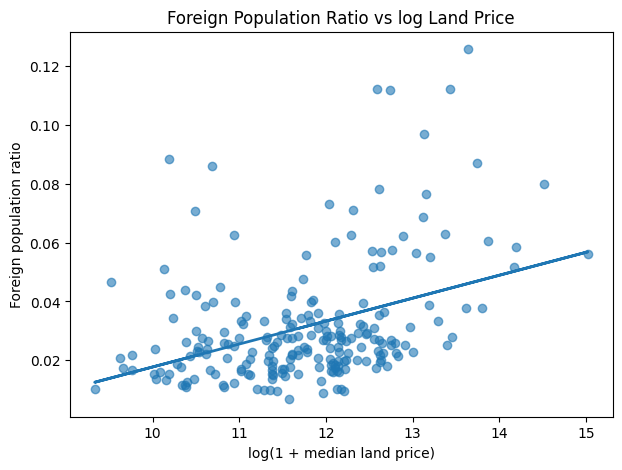

In [30]:
fig, ax = plt.subplots(figsize=(7, 5))

x = tokyo_proj["log_median_land_price_jpy"]
y = tokyo_proj["foreign_ratio"]

mask = x.notna() & y.notna()

ax.scatter(x[mask], y[mask], alpha=0.6)

z = np.polyfit(x[mask], y[mask], 1)
p = np.poly1d(z)
ax.plot(x[mask], p(x[mask]), linewidth=2)

ax.set_xlabel("log(1 + median land price)")
ax.set_ylabel("Foreign population ratio")
ax.set_title("Foreign Population Ratio vs log Land Price")

plt.show()

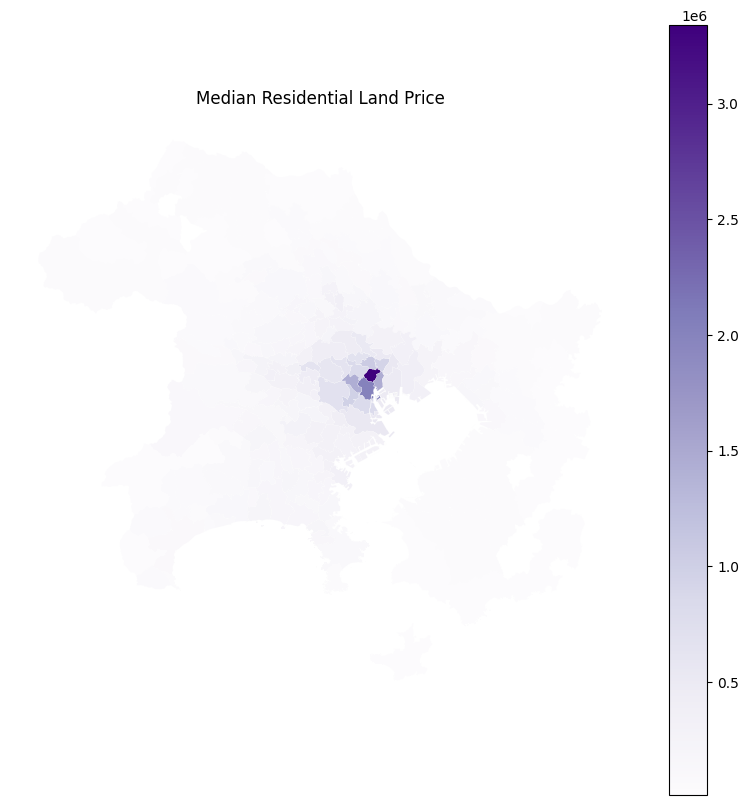

In [31]:
fig, ax = plt.subplots(figsize=(10, 10))

tokyo_proj.plot(
    column="median_land_price_jpy",
    cmap="Purples",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title("Median Residential Land Price")
ax.set_axis_off()
plt.show()

## Preliminary findings from the two-variable EDA

1. Station accessibility remains an important factor. The foreign population ratio is negatively correlated with log station distance (-0.33), suggesting that better railway accessibility is associated with higher foreign population shares.

2. Median residential land price also shows a positive relationship with foreign population ratio (0.39). This indicates that foreign population concentration in the Tokyo metropolitan mainland area is not simply a low-cost peripheral phenomenon.

3. Land price and station accessibility are moderately correlated (-0.52), which reflects the broader urban spatial structure: higher-value areas tend to be closer to railway stations.

4. The results suggest that foreign population distribution in the Tokyo metropolitan area is shaped by both accessibility and urban economic value, rather than by a single cost-minimization logic.

5. These findings justify the inclusion of both log station distance and log median residential land price in the next-stage regression analysis.

In [32]:
model_df = tokyo_proj[[
    "N03_007", "N03_001", "N03_004", "N03_005",
    "foreign_ratio",
    "dist_to_station_m", "log_dist_to_station_m",
    "median_land_price_jpy", "log_median_land_price_jpy",
    "geometry"
]].copy()

print(model_df.shape)

(227, 10)


In [33]:
model_df = model_df.dropna(subset=["foreign_ratio", "log_dist_to_station_m", "log_median_land_price_jpy"]).copy()

print(model_df.shape)
model_df[["foreign_ratio", "log_dist_to_station_m", "log_median_land_price_jpy"]].isna().sum()

(218, 10)


foreign_ratio                0
log_dist_to_station_m        0
log_median_land_price_jpy    0
dtype: int64

In [34]:
week6_geojson = data_raw / "tokyo_features_v2.geojson"
model_df.to_file(week6_geojson, driver="GeoJSON")

model_df.drop(columns="geometry").to_csv(
    data_raw / "tokyo_features_v2.csv",
    index=False,
    encoding="utf-8-sig"
)

print(week6_geojson)
print(week6_geojson.exists())

e:\rsch\laborJapan\data_raw\tokyo_features_v2.geojson
True
